### ANALYZING JOB APPLICATION TRENDS IN THE APPLICANT SPACE
#### Creating predictive model to determine the Application status for Applicant
##### Applicants has been facing challenges in the job market
* Jobs that best suits them
* Prediciting their chances of securing an interview
* Determine if their skills are a perfect match



####  Applicant Role Classifier
#####  Framework : scikit-learn
#####  Labels    : Best Suited for Role | Best Match for Role |
#####              Will Get Interview

#### Case Study: Predicting Application Status of Applicants
##### Project to enhance Applicant Application Status
##### 1.Project Problem Understanding
##### 2.Data Preprocessing and Cleaning
##### 3.Addressing Class Imbalance
##### 4.Model Development and Evaluation
##### 5.Interpreting Model Results¶
##### 6.AutoML Techniques

# ---
## Section 1: Import libraries 🤔

In [145]:
# Import libraries

import  pandas as pd   #dataframes for working with tabular data
import numpy  as np  # numerical operations

#visulization
import matplotlib.pyplot as plt 
import seaborn as sns

#scikit learn  machine learning 
# Machine preprocessing 
from sklearn.model_selection import train_test_split   # split data into train/test sets
from sklearn.preprocessing import StandardScaler  # standardize numerical features / columns
from sklearn.preprocessing import LabelEncoder  # Encode categorical columns


#machine learning Model 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 


# Machine Learning Evaluation

from sklearn.metrics import (accuracy_score, 
                               precision_score, 
                               recall_score, 
                               f1_score, 
                               confusion_matrix,
                               classification_report, 
                               roc_auc_score,
                               roc_curve)

#Setting
import warnings
warnings.filterwarnings('ignore')

sns.set_style ('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

#Set random seed for reproducility

RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


In [146]:
Data_booking = "applicant_dataset_imbalanced.csv" 

df = pd.read_csv(Data_booking)

print("Data loaded successfully!")
print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("data loaded successfully")

Data loaded successfully!
shape: 1000 rows x 14 columns
data loaded successfully


# ---
## Section 2: Data Understanding

In [147]:
#### lets look at what we are working with, lets see the first 5 rows

### Print top 5 Rows

df.head(10)

,id,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1,3,HS,0.97,0,0,2,1,4,68,0,0,0,Will Get Interview
1,2,2,HS,0.37,2,2,8,2,5,173,1,0,0,Best Match for Role
2,3,1,HS,0.71,0,1,1,6,5,62,0,0,0,Will Get Interview
3,4,10,PhD,0.99,3,1,2,1,10,135,0,1,0,Best Suited for Role
4,5,1,HS,0.05,4,0,2,6,1,79,0,1,2,Will Get Interview
5,6,0,HS,0.35,1,0,3,4,4,145,0,0,1,Will Get Interview
6,7,2,HS,0.41,3,1,2,5,3,168,0,0,0,Will Get Interview
7,8,9,Bachelor,0.43,12,5,7,2,9,85,0,1,3,Best Suited for Role
8,9,8,HS,0.20,1,0,9,1,2,194,0,0,0,Will Get Interview
9,10,1,HS,0.40,0,0,4,6,2,56,0,0,1,Will Get Interview


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1000 non-null   int64  
 1   years_experience       1000 non-null   int64  
 2   education_level        1000 non-null   object 
 3   skills_match_score     1000 non-null   float64
 4   num_relevant_projects  1000 non-null   int64  
 5   certifications         1000 non-null   int64  
 6   communication_score    1000 non-null   int64  
 7   leadership_score       1000 non-null   int64  
 8   culture_fit_score      1000 non-null   int64  
 9   previous_salary_k      1000 non-null   int64  
 10  location_match         1000 non-null   int64  
 11  applied_before         1000 non-null   int64  
 12  num_interviews_passed  1000 non-null   int64  
 13  label                  1000 non-null   object 
dtypes: float64(1), int64(11), object(2)
memory usage: 109.5+ 

In [149]:
df.describe()


,id,years_experience,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000,1000.000000,1000.000000,1000.000000
mean,500.500000,5.363000,0.276720,3.37400,2.187000,3.944000,4.497000,3.966000,112.220,0.220000,0.432000,0.687000
std,288.819436,6.306743,0.246708,3.66327,2.182841,2.544275,2.909718,2.674322,52.036,0.414454,0.495602,1.096464
min,1.000000,0.000000,0.000000,0.00000,0.000000,1.000000,1.000000,1.000000,20.000,0.000000,0.000000,0.000000
25%,250.750000,1.000000,0.080000,1.00000,0.000000,2.000000,2.000000,2.000000,68.000,0.000000,0.000000,0.000000
50%,500.500000,3.000000,0.200000,2.00000,1.000000,3.000000,4.000000,3.000000,112.000,0.000000,0.000000,0.000000
75%,750.250000,7.000000,0.410000,5.00000,3.000000,5.000000,7.000000,6.000000,157.000,0.000000,1.000000,1.000000
max,1000.000000,30.000000,0.990000,15.00000,8.000000,10.000000,10.000000,10.000000,200.000,1.000000,1.000000,4.000000


In [150]:
df.describe(include=["object", "bool"])

,education_level,label
count,1000,1000
unique,4,3
top,HS,Will Get Interview
freq,729,550


### Handling Missing Values

In [151]:
df.duplicated().sum()

np.int64(0)

#### No Duplicate

In [152]:
df.isnull().sum()

id                       0
years_experience         0
education_level          0
skills_match_score       0
num_relevant_projects    0
certifications           0
communication_score      0
leadership_score         0
culture_fit_score        0
previous_salary_k        0
location_match           0
applied_before           0
num_interviews_passed    0
label                    0
dtype: int64

In [153]:
df.head()

,id,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1,3,HS,0.97,0,0,2,1,4,68,0,0,0,Will Get Interview
1,2,2,HS,0.37,2,2,8,2,5,173,1,0,0,Best Match for Role
2,3,1,HS,0.71,0,1,1,6,5,62,0,0,0,Will Get Interview
3,4,10,PhD,0.99,3,1,2,1,10,135,0,1,0,Best Suited for Role
4,5,1,HS,0.05,4,0,2,6,1,79,0,1,2,Will Get Interview


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1000 non-null   int64  
 1   years_experience       1000 non-null   int64  
 2   education_level        1000 non-null   object 
 3   skills_match_score     1000 non-null   float64
 4   num_relevant_projects  1000 non-null   int64  
 5   certifications         1000 non-null   int64  
 6   communication_score    1000 non-null   int64  
 7   leadership_score       1000 non-null   int64  
 8   culture_fit_score      1000 non-null   int64  
 9   previous_salary_k      1000 non-null   int64  
 10  location_match         1000 non-null   int64  
 11  applied_before         1000 non-null   int64  
 12  num_interviews_passed  1000 non-null   int64  
 13  label                  1000 non-null   object 
dtypes: float64(1), int64(11), object(2)
memory usage: 109.5+ 

In [155]:
df = df.drop(columns=["id"])

In [156]:
numerical_columns = df.select_dtypes(include="number")
print(len(numerical_columns.columns))

11


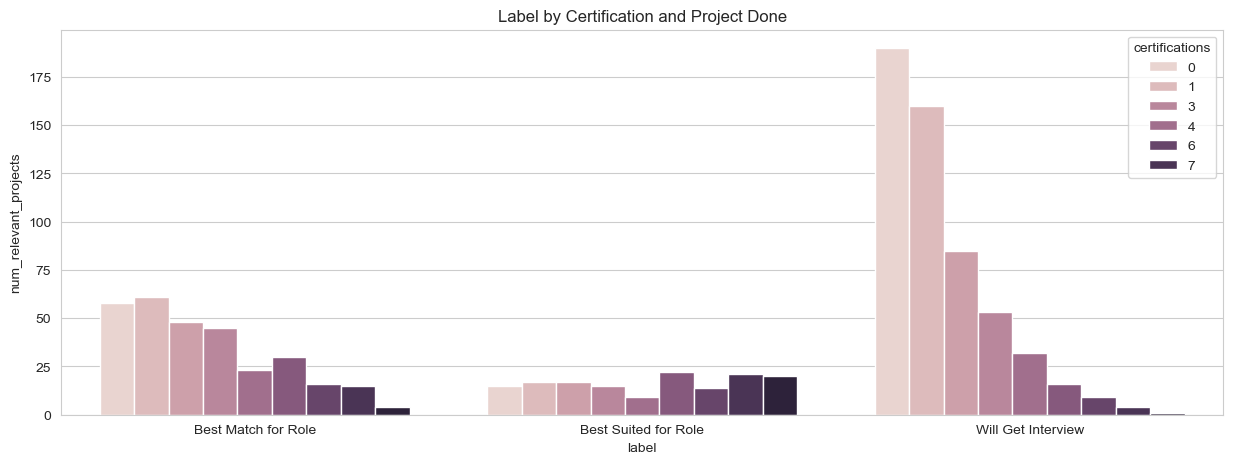

In [157]:
labelsmatch = df.groupby(["label", "certifications"])["num_relevant_projects"].count().reset_index()

plt.figure(figsize=(15,5))
sns.barplot(x="label",y="num_relevant_projects",data=labelsmatch,hue="certifications")

plt.title("Label by Certification and Project Done")
plt.show()

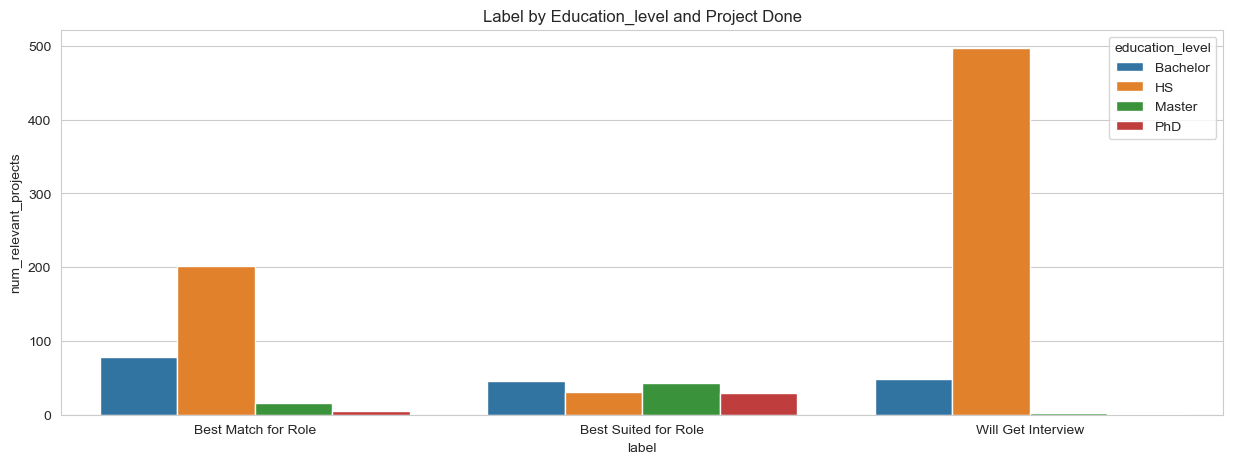

In [158]:
labelsmatch = df.groupby(["label", "education_level"])["num_relevant_projects"].count().reset_index()

plt.figure(figsize=(15,5))
sns.barplot(x="label",y="num_relevant_projects",data=labelsmatch,hue="education_level")

plt.title("Label by Education_level and Project Done")
plt.show()

Best Suited for Role (2): 150  (15.0%)
Best Match for Role (1):    300  (30.0%)
Will Get Interview (0):    550  (55.0%)


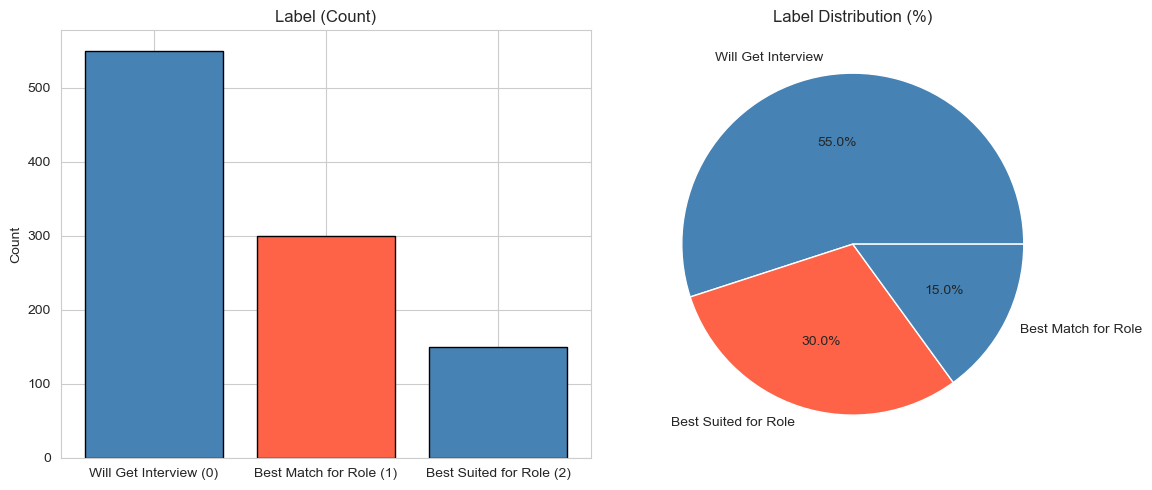

In [221]:
df_pro = df.copy()

target_counts = df_pro['label'].value_counts()
target_pct = df_pro['label'].value_counts(normalize=True) * 100

print(f"Best Suited for Role (2): {target_counts.iloc[2]:,}  ({target_pct.iloc[2]:.1f}%)")
print(f"Best Match for Role (1):    {target_counts.iloc[1]:,}  ({target_pct.iloc[1]:.1f}%)")
print(f"Will Get Interview (0):    {target_counts.iloc[0]:,}  ({target_pct.iloc[0]:.1f}%)")

# Visualize Best Match for Role
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Will Get Interview (0)', 'Best Match for Role (1)', 'Best Suited for Role (2)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Label (Count)')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=['Will Get Interview', 'Best Suited for Role', 'Best Match for Role'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Label Distribution (%)')

plt.tight_layout()
plt.show()

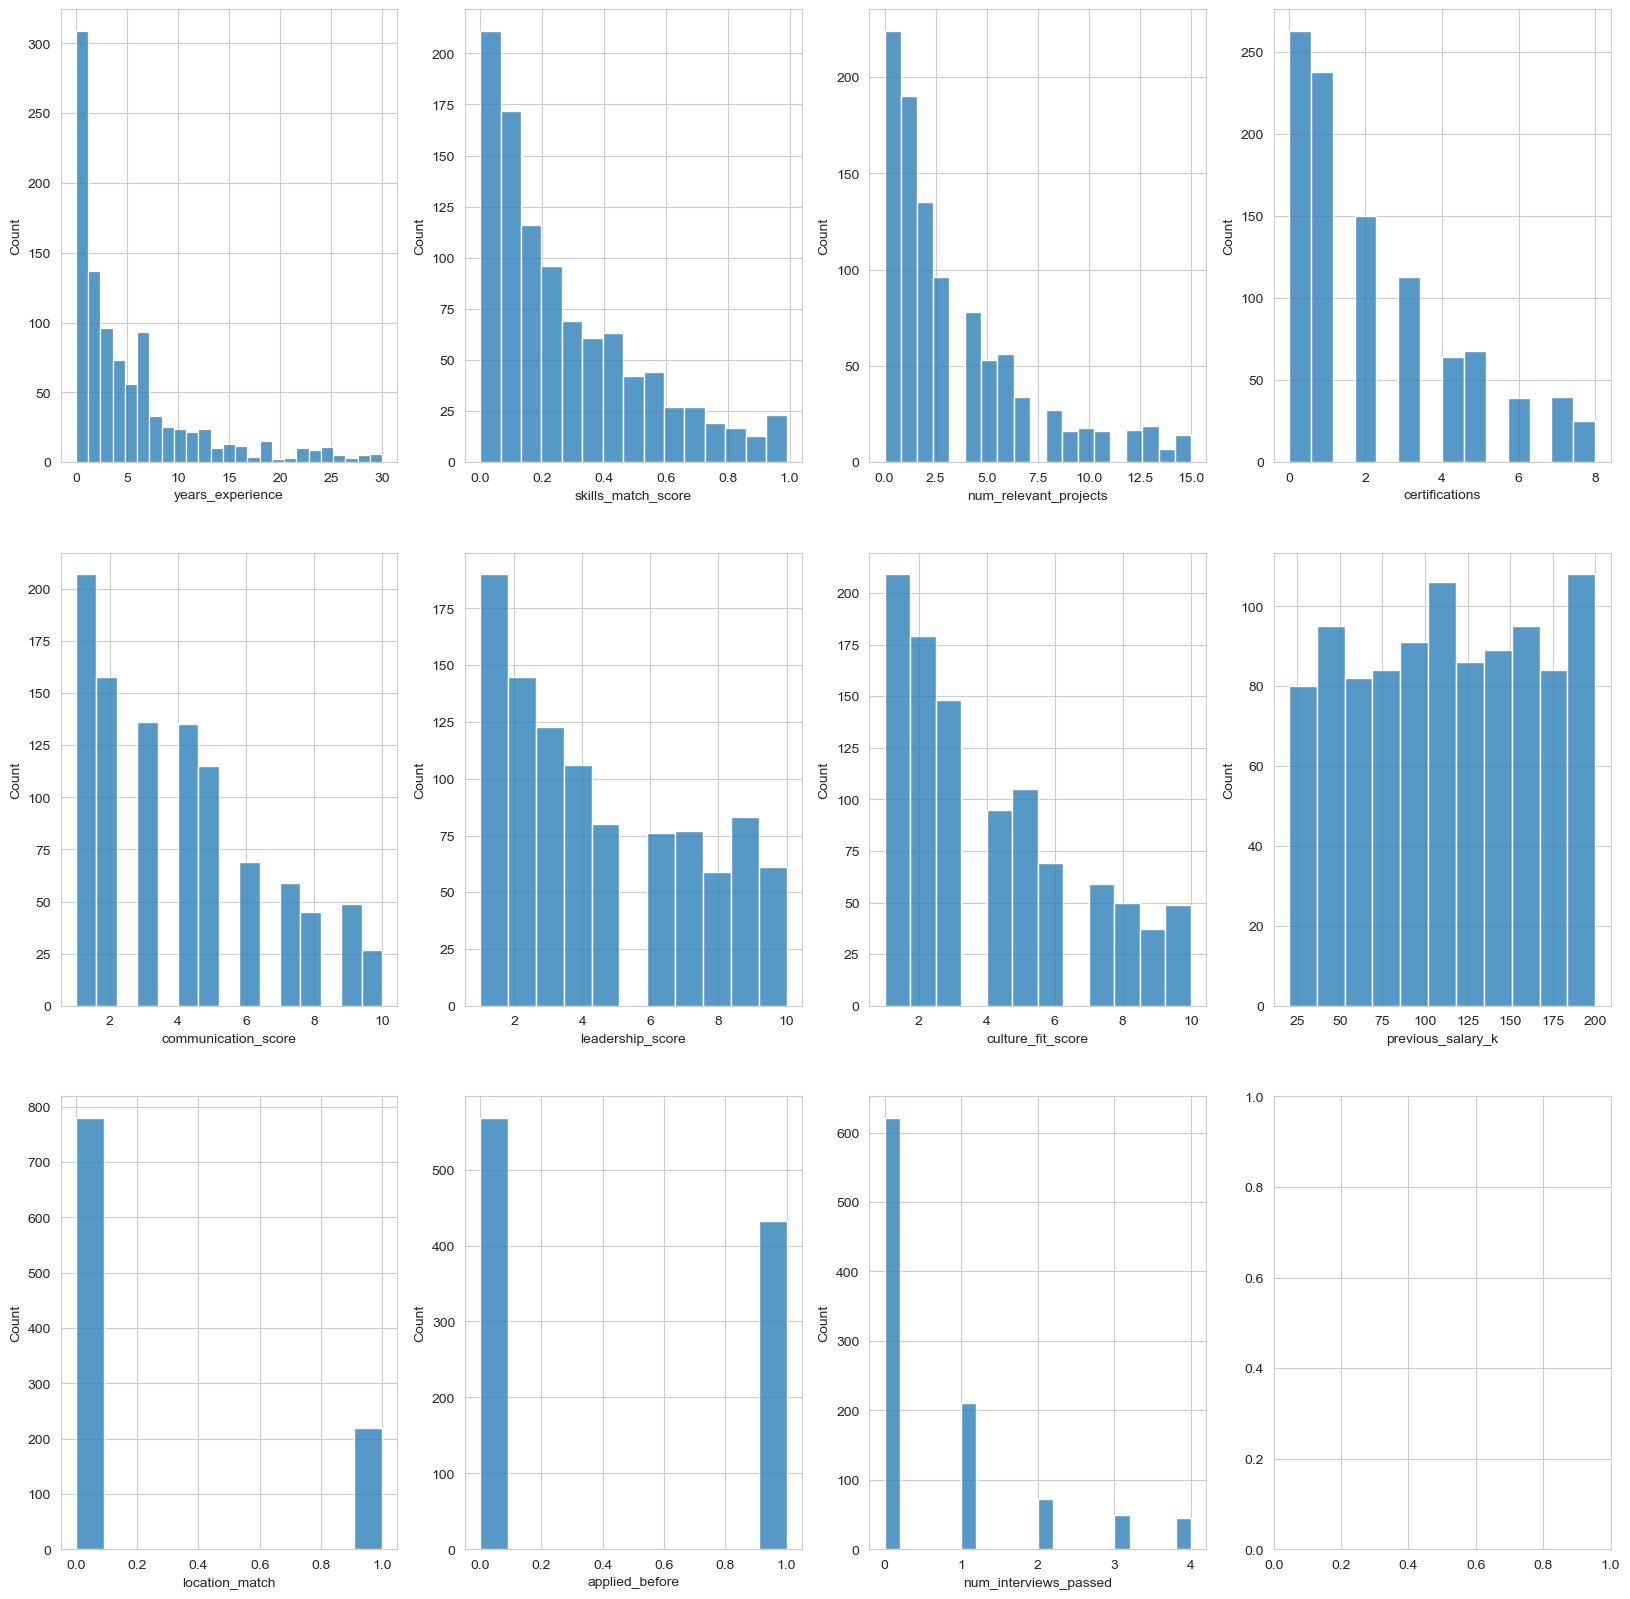

In [160]:
fig, ax = plt.subplots(nrows=3,ncols=4, figsize=(20,20))
ax = ax.flatten()
for am, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=ax[am])
plt.show()

In [161]:
df.head()

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,3,HS,0.97,0,0,2,1,4,68,0,0,0,Will Get Interview
1,2,HS,0.37,2,2,8,2,5,173,1,0,0,Best Match for Role
2,1,HS,0.71,0,1,1,6,5,62,0,0,0,Will Get Interview
3,10,PhD,0.99,3,1,2,1,10,135,0,1,0,Best Suited for Role
4,1,HS,0.05,4,0,2,6,1,79,0,1,2,Will Get Interview


In [162]:
num_col_names = numerical_columns.columns.tolist()

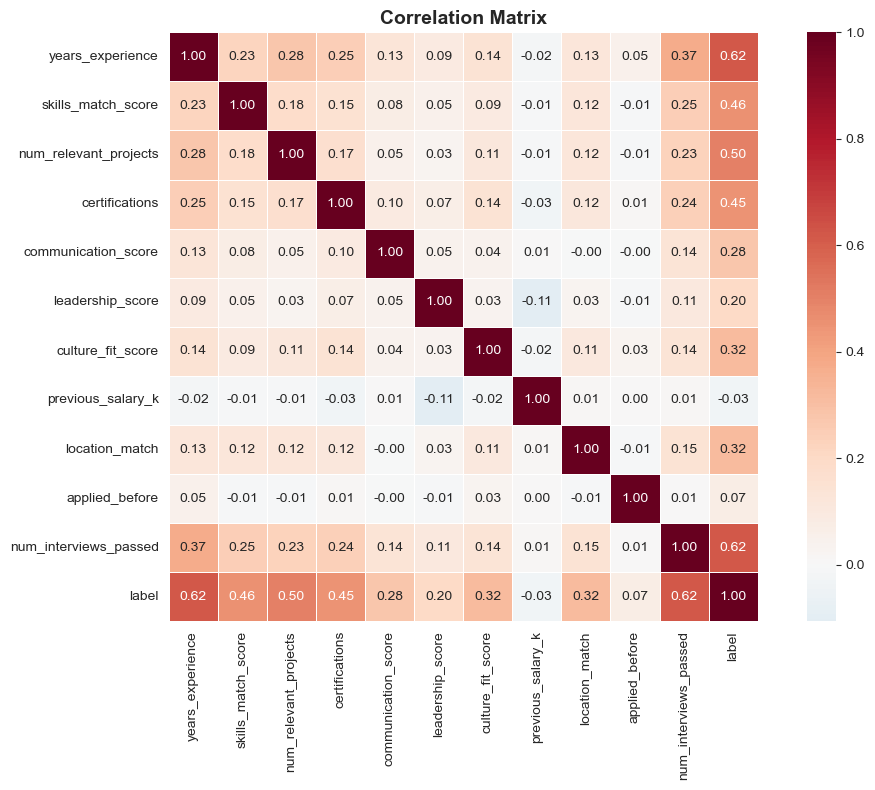

Correlations with booking (sorted):
years_experience         0.624156
num_interviews_passed    0.615648
num_relevant_projects    0.503457
skills_match_score       0.456275
certifications           0.449586
location_match           0.318652
culture_fit_score        0.315848
communication_score      0.280727
leadership_score         0.200175
applied_before           0.073624
previous_salary_k       -0.029671
Name: label, dtype: float64


In [163]:
# Correlation heatmap — shows relationships between numerical features and labels

# Values closer to +1 or -1 = stronger relationship

#### Mapping the column booking status with 0 and 1 to enbble pandas read it

df_pro['label'] = df_pro['label'].map({'Will Get Interview': 0, 'Best Match for Role': 1, 'Best Suited for Role': 2 })

corr_cols = num_col_names + ['label']
correlation_matrix = df_pro[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show which features correlate most with the target
print("Correlations with booking (sorted):")
print(correlation_matrix['label'].drop('label').sort_values(key=abs, ascending=False))

In [164]:
# TASK: Find the top 3 features most correlated with the target variable
# HINT: First, create a correlation series: corr = df.corr()
# HINT: Get absolute values and sort in descending order
# HINT: Extract indices [1:4] (skip the first which is the target with itself)

# Get correlation with target, take absolute values, and sort
corr_target = correlation_matrix["label"].abs().sort_values(ascending=False)

# Get top 3 features (excluding the target itself)
top_3_features = corr_target[1:4]

print(top_3_features)

years_experience         0.624156
num_interviews_passed    0.615648
num_relevant_projects    0.503457
Name: label, dtype: float64


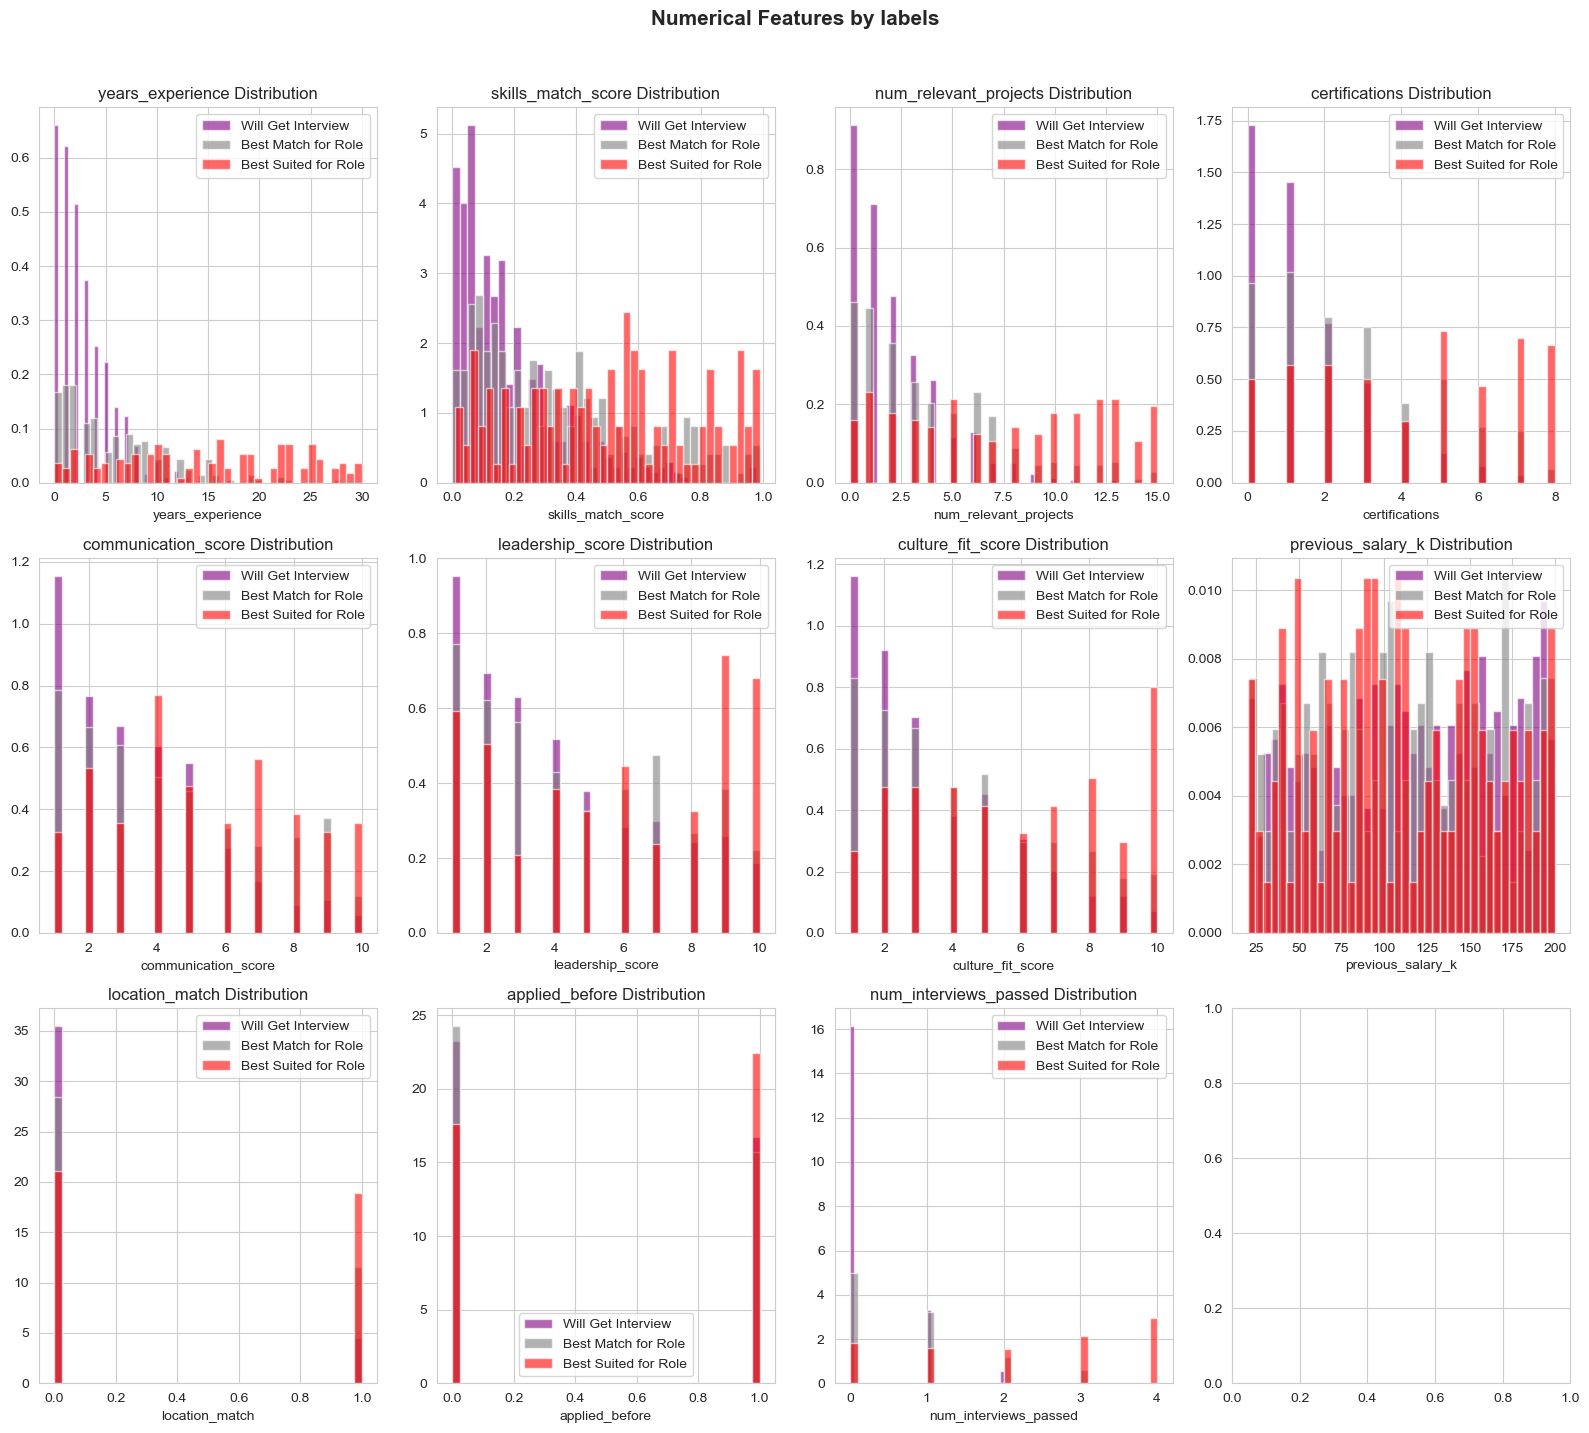

In [166]:
# Distributions of numerical features — split by Labels

# Purple= Will Get Interview, Grey = Best Match for Role,  Red = Best Suited for Role

fig, axes = plt.subplots(3, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_col_names):
    axes[i].hist(df_pro[df_pro['label'] == 0][col], bins=40, alpha=0.6,
                 color='purple', label='Will Get Interview', density=True)
    axes[i].hist(df_pro[df_pro['label'] == 1][col], bins=40, alpha=0.6,
                 color='grey', label='Best Match for Role', density=True)
    axes[i].hist(df_pro[df_pro['label'] == 2][col], bins=40, alpha=0.6,
                 color='red', label='Best Suited for Role', density=True)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].legend()
     

plt.suptitle('Numerical Features by labels', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [167]:
cat_columns = df.select_dtypes(include=["object", "bool"])
print(len(cat_columns.columns))

2


In [168]:
cat_col_names = cat_columns.columns.tolist()
print(cat_col_names)

['education_level', 'label']


education_level  label               
Bachelor         Best Match for Role      78
                 Will Get Interview       49
                 Best Suited for Role     46
HS               Will Get Interview      497
                 Best Match for Role     201
                 Best Suited for Role     31
Master           Best Suited for Role     43
                 Best Match for Role      16
                 Will Get Interview        3
PhD              Best Suited for Role     30
                 Best Match for Role       5
                 Will Get Interview        1
Name: count, dtype: int64


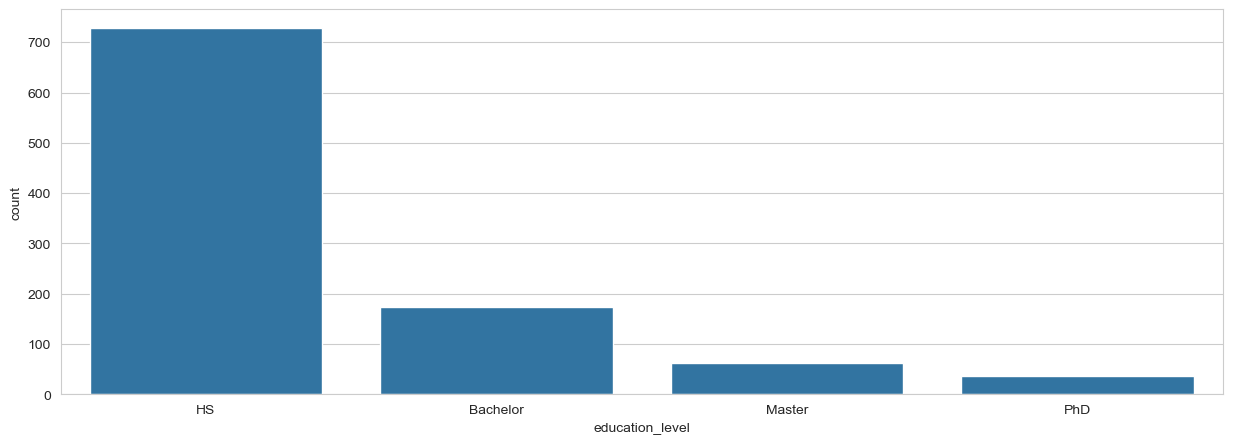

In [169]:
education_label = df.groupby("education_level")["label"].value_counts()

print(education_label)

plt.figure(figsize=(15,5))

topten = df["education_level"].value_counts().head(10)

sns.countplot(x="education_level", data=df, order=topten.index);

In [170]:
df.head()

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,3,HS,0.97,0,0,2,1,4,68,0,0,0,Will Get Interview
1,2,HS,0.37,2,2,8,2,5,173,1,0,0,Best Match for Role
2,1,HS,0.71,0,1,1,6,5,62,0,0,0,Will Get Interview
3,10,PhD,0.99,3,1,2,1,10,135,0,1,0,Best Suited for Role
4,1,HS,0.05,4,0,2,6,1,79,0,1,2,Will Get Interview


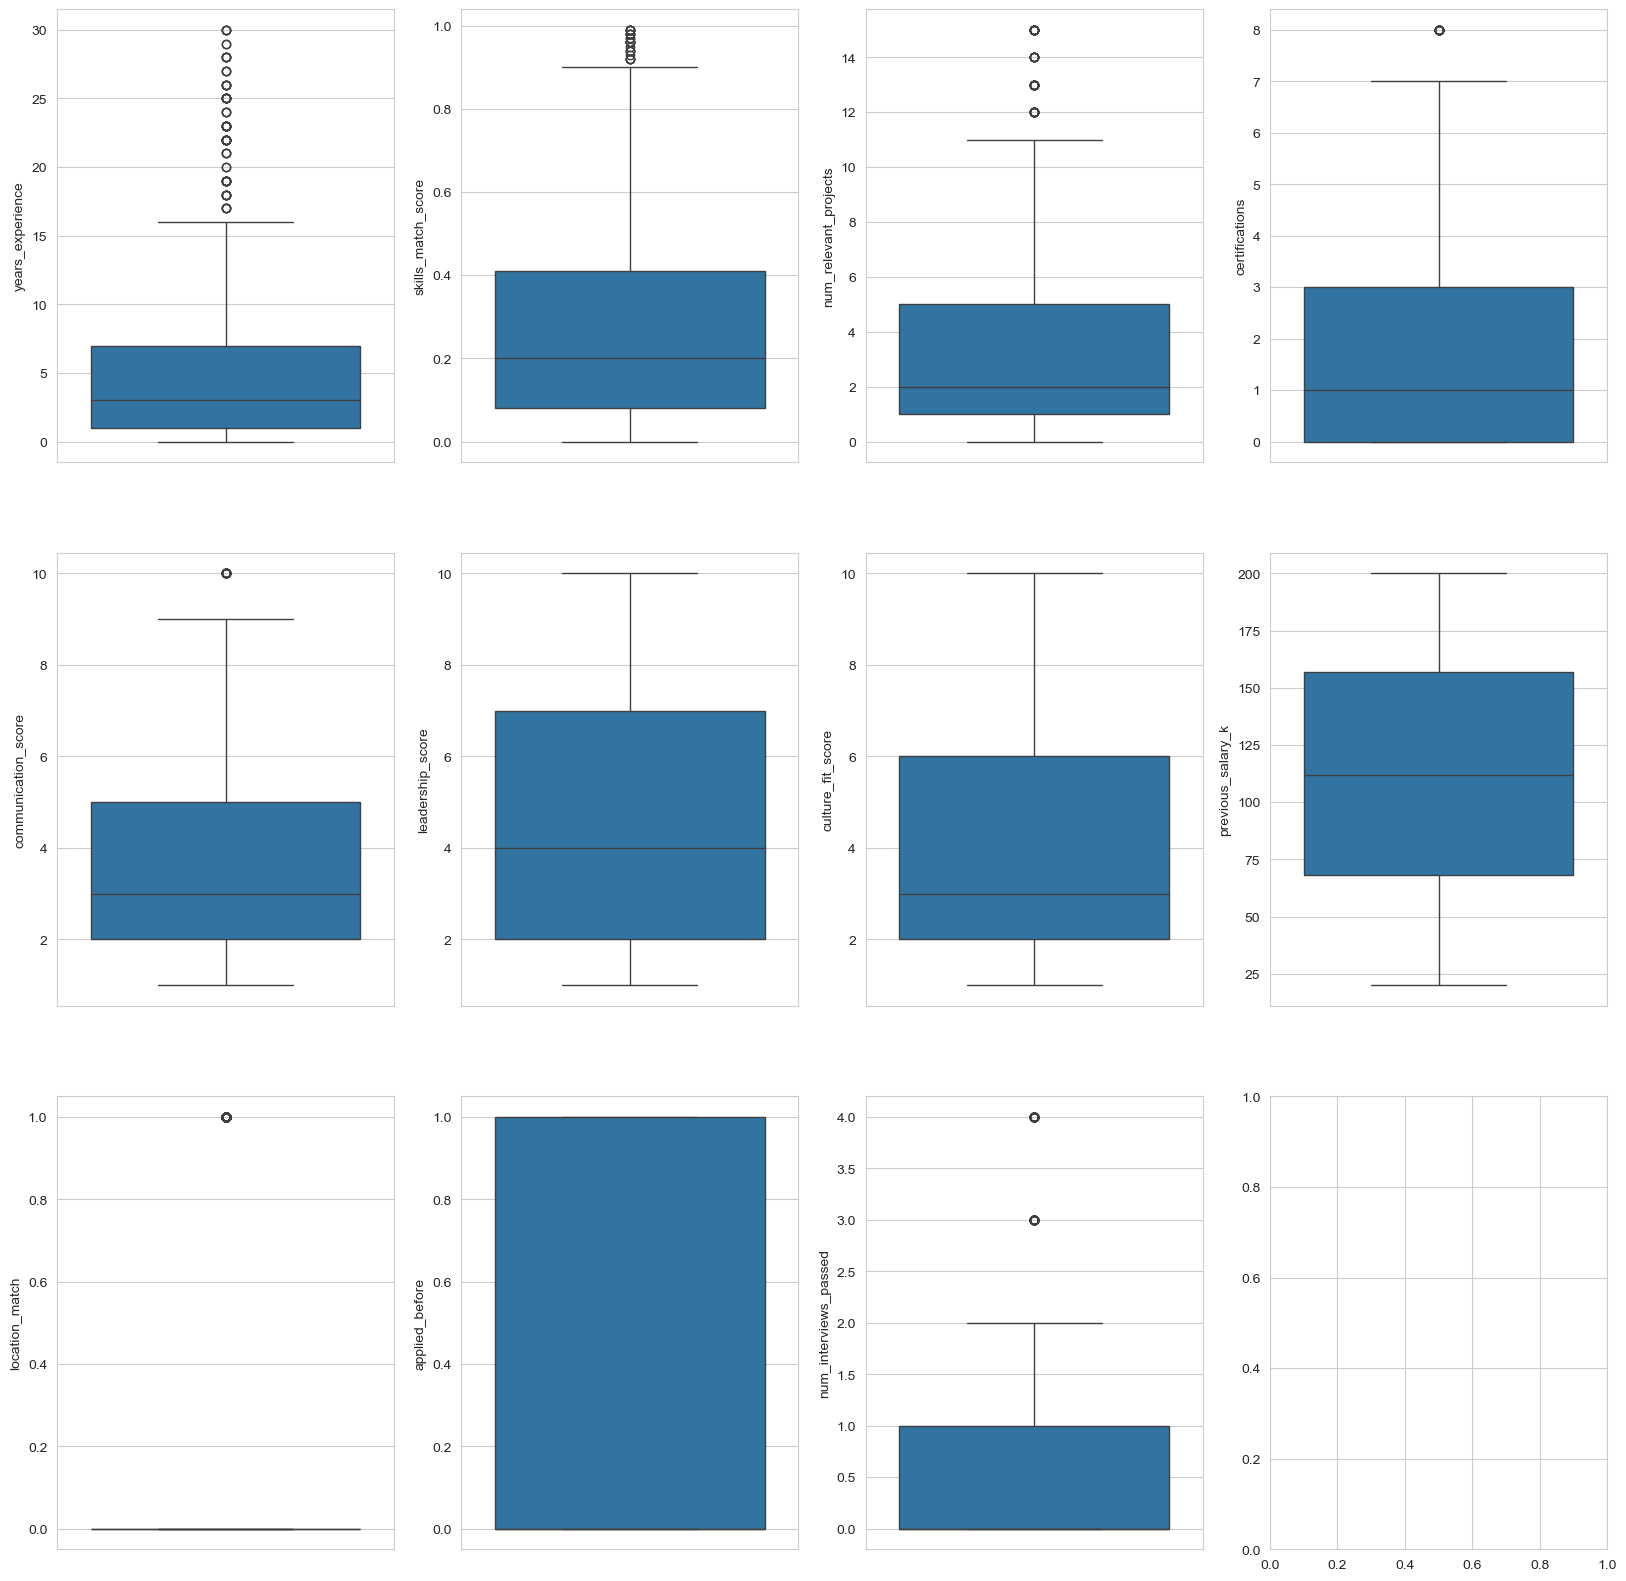

In [171]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(20,20))
ax = ax.flatten()
for am, col in enumerate(num_col_names):
    sns.boxplot(df[col], ax=ax[am]) 
plt.show()

#### Handling Outliers
##### * Years_Experience, 
##### * Num_Relevant_Projects

In [172]:
outlier_column = ["years_experience", "num_relevant_projects"]

In [173]:
q1 = df[outlier_column].quantile(0.25)
q3 = df[outlier_column].quantile(0.75)

In [174]:
iqr = q3-q1

In [175]:
lower_bound = q1 -  (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

In [176]:
df[outlier_column] = df[outlier_column].clip(lower = lower_bound, upper = upper_bound, axis=1)

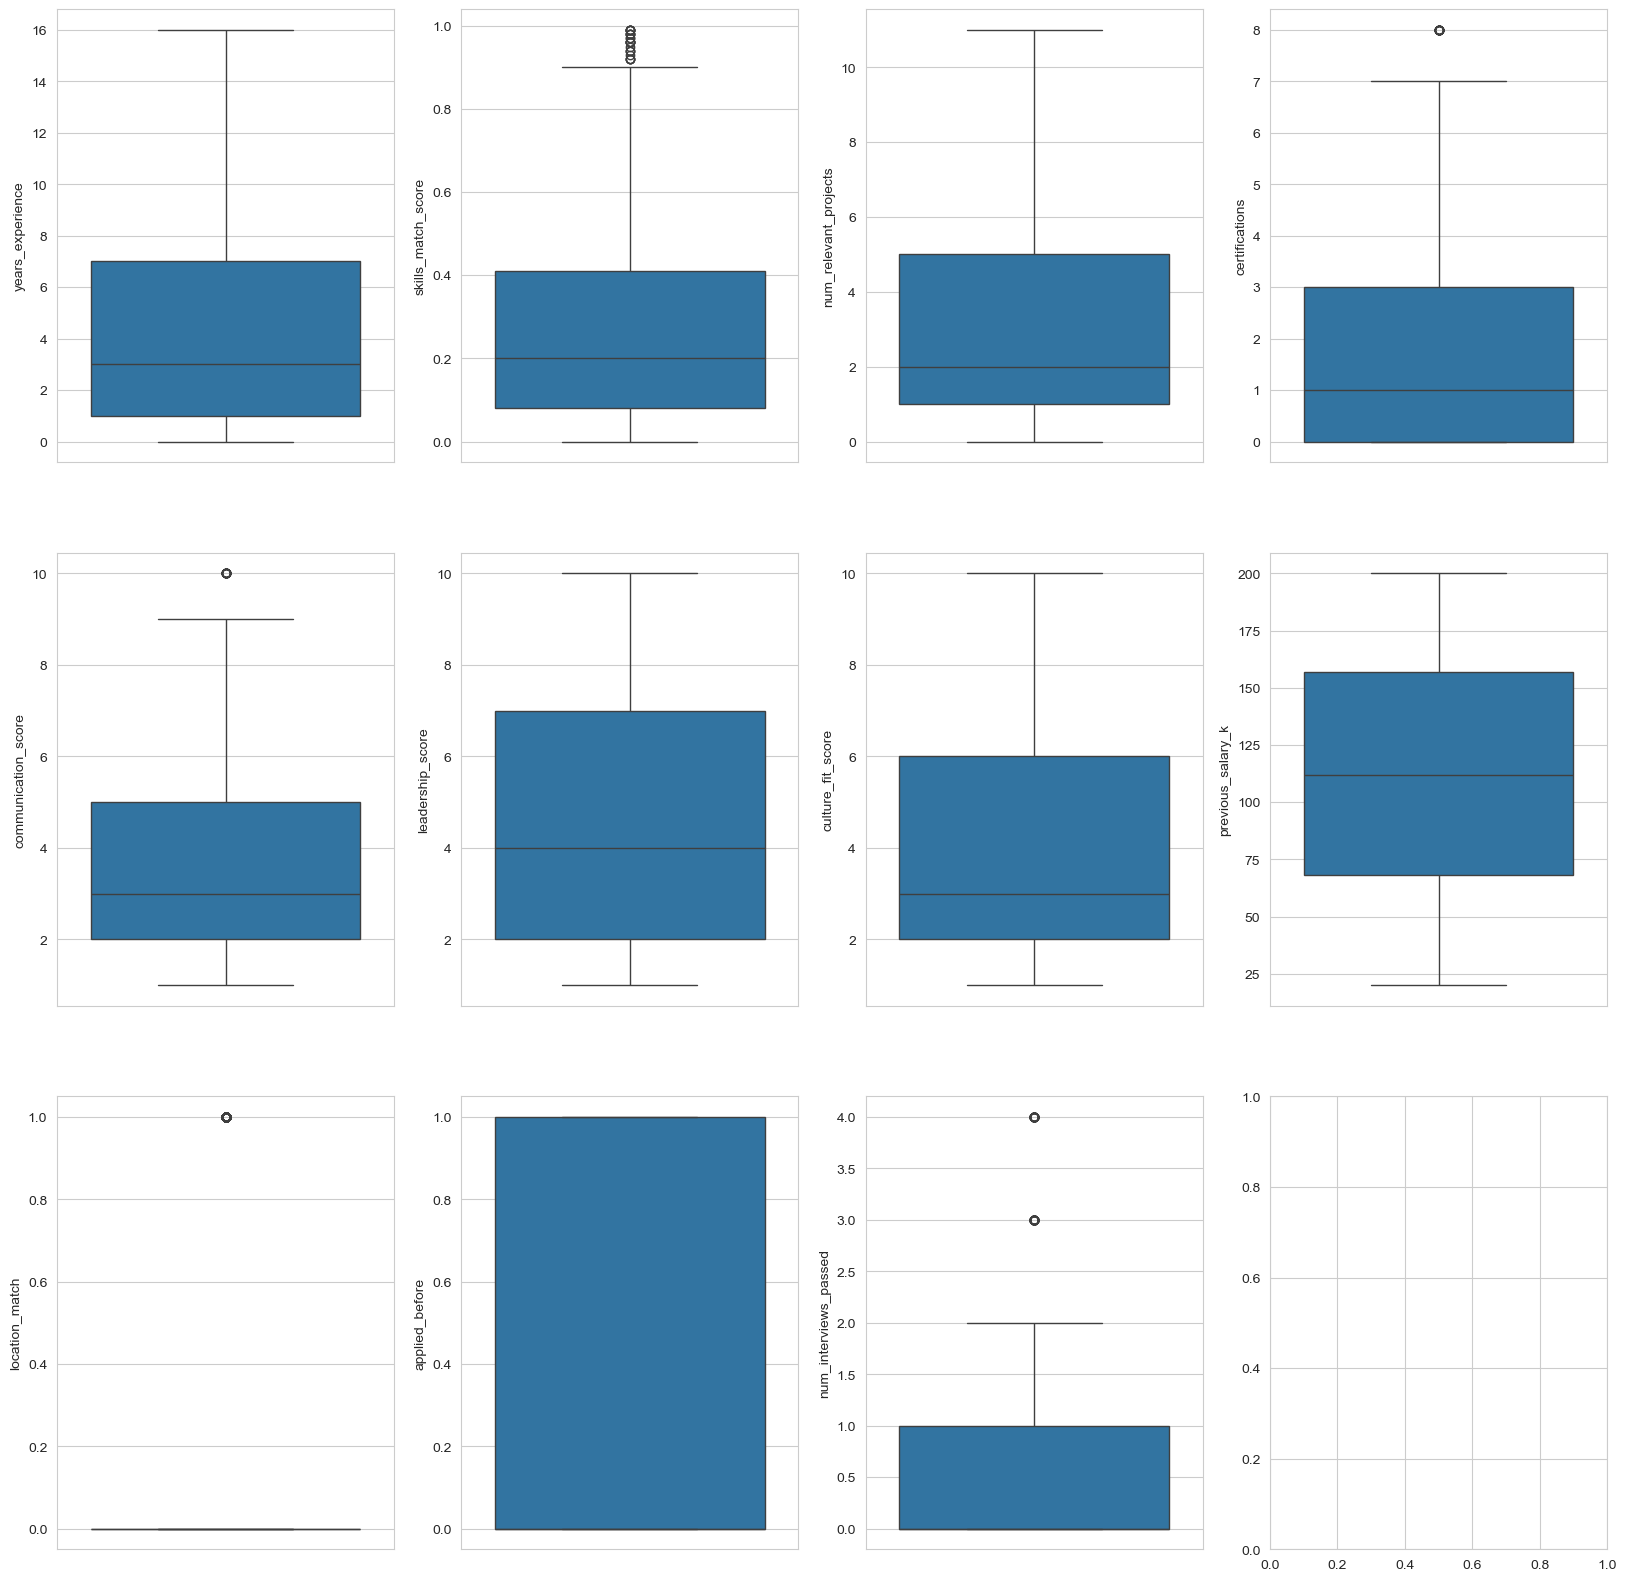

In [177]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(20,20))
ax = ax.flatten()
for am, col in enumerate(num_col_names):
    sns.boxplot(df[col], ax=ax[am]) 
plt.show()

In [178]:
df.columns

Index(['years_experience', 'education_level', 'skills_match_score',
       'num_relevant_projects', 'certifications', 'communication_score',
       'leadership_score', 'culture_fit_score', 'previous_salary_k',
       'location_match', 'applied_before', 'num_interviews_passed', 'label'],
      dtype='object')

### Training the Dataset
---
##  Data Preprocessing

ML models only understand **numbers**. We need to convert text/categories to numerical format.

**Encoding strategies:**
- **Binary map (Yes→1, No→0)** for columns with only two values
- **One-Hot Encoding** for categories with no natural order (creates a new 0/1 column per category)

**Feature Scaling:**  
- `StandardScaler` transforms each feature to have **mean=0** and **standard deviation=1**  
- Prevents features with large values from dominating the model
- #### ---------------
###### * Transform the data set
###### * Standardize the data set
###### * Split and Train the data set
###### * Run the model to prdeict
###### * Validate the Model

In [ ]:
from sklearn.preprocessing import StandardScaler

In [120]:
!pip install scikit_learn

In [121]:
encoder =LabelEncoder()

In [179]:
df["education_level"] = encoder.fit_transform(df["education_level"])

---
## Split Features/Target & Train/Test Split

- **X** = all input features (what the model uses to predict)
- **y** = the target variable (what we want to predict)

We split data into **80% training** and **20% test** sets.  
The model learns on training data and is evaluated on unseen test data.

> **`stratify=y`** ensures the same default/no-default ratio in both splits.

In [180]:
X = df.drop(columns=['label'])
y = df['label']

#### Split Features

In [182]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [183]:

# Step 1 — Split FIRST, before any resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2 — Apply SMOTE ONLY on training data
# NEVER apply it on test data — that would be data leakage
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 3 — Check the result
import pandas as pd
print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_resampled).value_counts().to_dict())

Before SMOTE: {'Will Get Interview': 440, 'Best Match for Role': 240, 'Best Suited for Role': 120}
After SMOTE : {'Best Suited for Role': 440, 'Will Get Interview': 440, 'Best Match for Role': 440}


#### Train Model

In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [185]:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, 
                                    max_depth=10, 
                                    random_state=42))
])

# Train on SMOTE-resampled data
pipeline.fit(X_train_resampled, y_train_resampled)

# Evaluate on ORIGINAL test data (never resampled)
from sklearn.metrics import classification_report
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

 Best Match for Role       0.80      0.82      0.81        60
Best Suited for Role       0.90      0.90      0.90        30
  Will Get Interview       0.93      0.92      0.92       110

            accuracy                           0.89       200
           macro avg       0.88      0.88      0.88       200
        weighted avg       0.89      0.89      0.89       200



#### Trying Out Mutliple Models

In [186]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [187]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42,class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)}

In [188]:
models.items()

dict_items([('Logistic Regression', LogisticRegression(class_weight='balanced', random_state=42)), ('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)), ('Gradient Boosting', GradientBoostingClassifier(random_state=42)), ('AdaBoost', AdaBoostClassifier(random_state=42)), ('SVM', SVC(class_weight='balanced', random_state=42)), ('KNN', KNeighborsClassifier()), ('Decision Tree', DecisionTreeClassifier(random_state=42))])

training Logistic Regression....
Logistic Regression Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.58      0.57      0.57        60
Best Suited for Role       0.60      0.80      0.69        30
  Will Get Interview       0.87      0.80      0.83       110

            accuracy                           0.73       200
           macro avg       0.68      0.72      0.70       200
        weighted avg       0.74      0.73      0.73       200



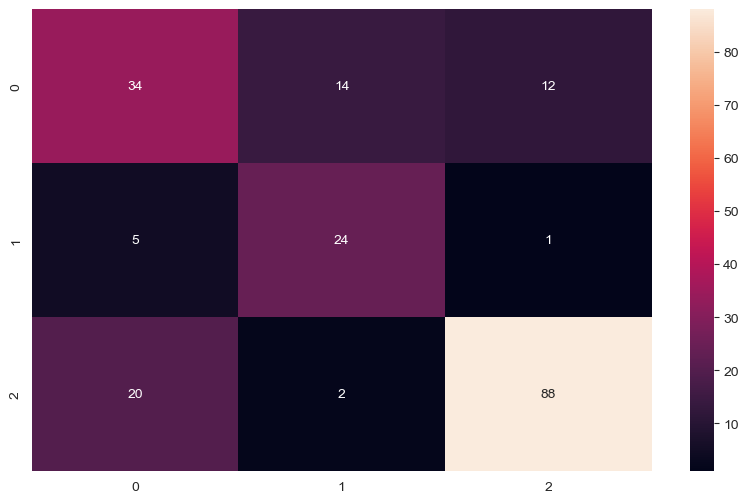

training Random Forest....
Random Forest Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.82      0.85      0.84        60
Best Suited for Role       0.90      0.93      0.92        30
  Will Get Interview       0.94      0.92      0.93       110

            accuracy                           0.90       200
           macro avg       0.89      0.90      0.89       200
        weighted avg       0.90      0.90      0.90       200



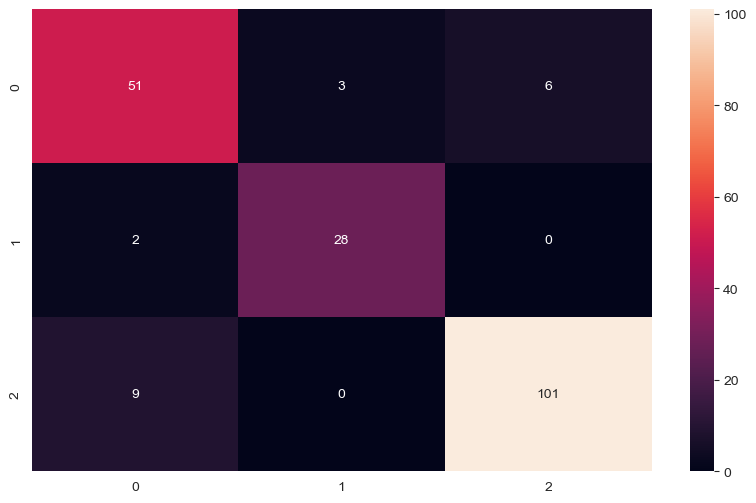

training Gradient Boosting....
Gradient Boosting Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.82      0.78      0.80        60
Best Suited for Role       0.82      0.93      0.88        30
  Will Get Interview       0.94      0.93      0.93       110

            accuracy                           0.89       200
           macro avg       0.86      0.88      0.87       200
        weighted avg       0.89      0.89      0.88       200



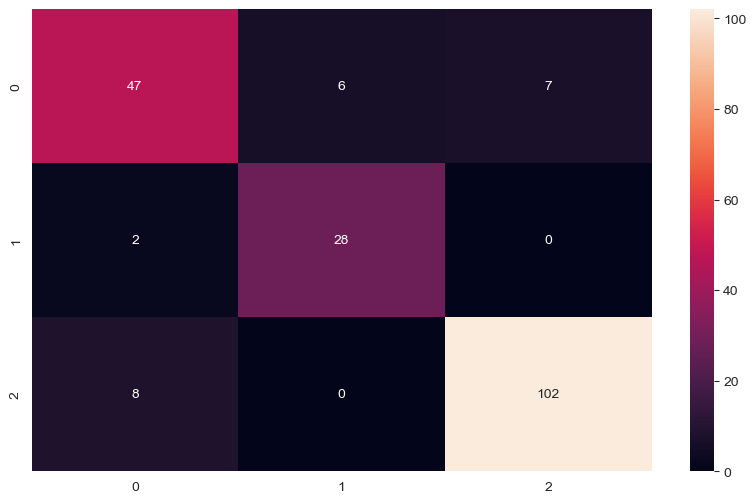

training AdaBoost....
AdaBoost Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.54      0.83      0.66        60
Best Suited for Role       0.91      0.97      0.94        30
  Will Get Interview       0.91      0.63      0.74       110

            accuracy                           0.74       200
           macro avg       0.79      0.81      0.78       200
        weighted avg       0.80      0.74      0.75       200



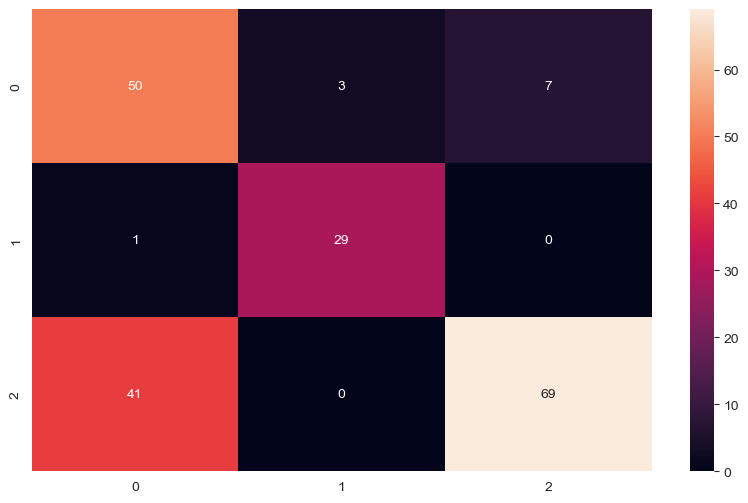

training SVM....
SVM Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.38      0.50      0.43        60
Best Suited for Role       0.67      0.73      0.70        30
  Will Get Interview       0.74      0.59      0.66       110

            accuracy                           0.58       200
           macro avg       0.60      0.61      0.60       200
        weighted avg       0.62      0.58      0.60       200



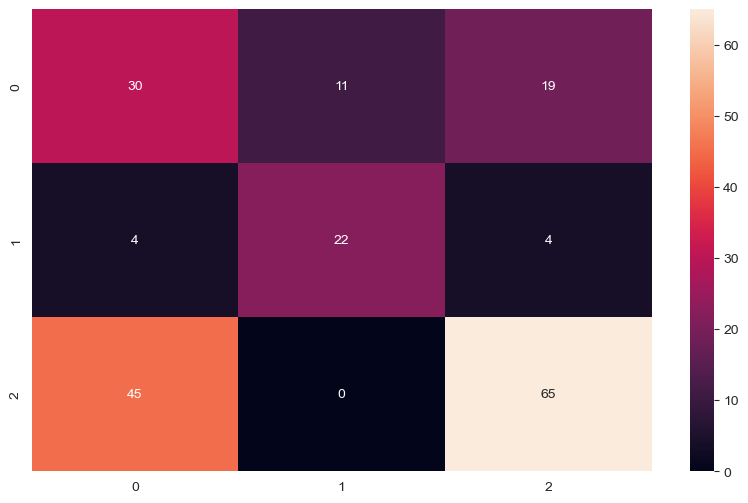

training KNN....
KNN Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.39      0.43      0.41        60
Best Suited for Role       0.56      0.63      0.59        30
  Will Get Interview       0.77      0.70      0.73       110

            accuracy                           0.61       200
           macro avg       0.57      0.59      0.58       200
        weighted avg       0.63      0.61      0.62       200



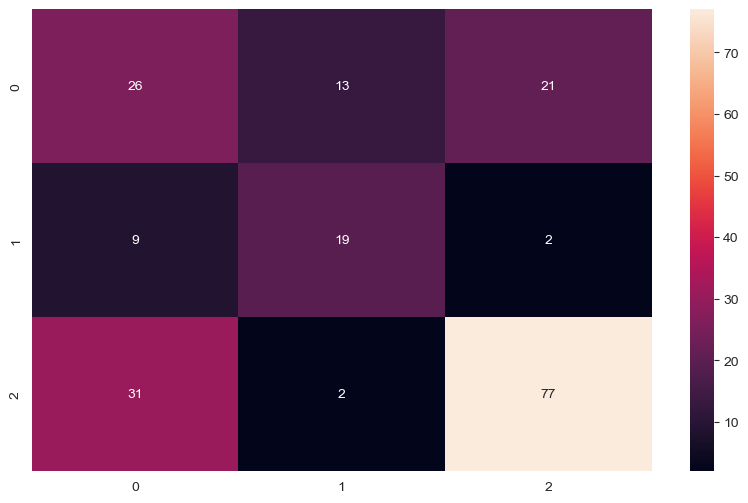

training Decision Tree....
Decision Tree Classification Report
                      precision    recall  f1-score   support

 Best Match for Role       0.60      0.72      0.65        60
Best Suited for Role       0.80      0.80      0.80        30
  Will Get Interview       0.86      0.76      0.81       110

            accuracy                           0.76       200
           macro avg       0.75      0.76      0.75       200
        weighted avg       0.77      0.76      0.76       200



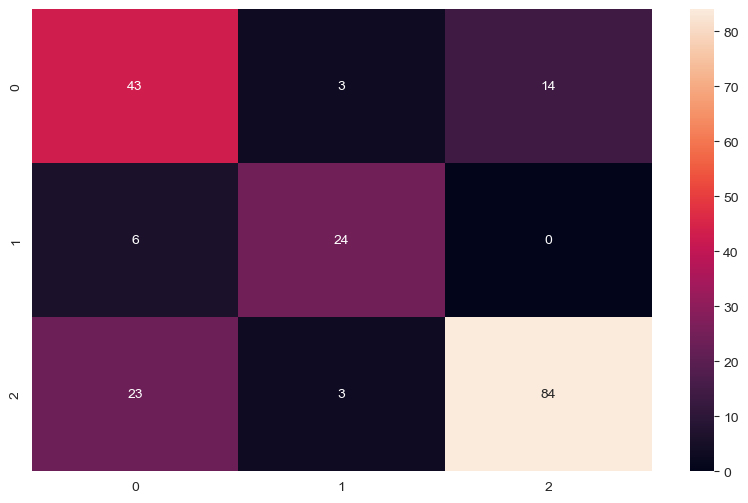

In [189]:
results = {}
for model_name, model in models.items():
    print(f"training {model_name}....")
    #training the model
    model.fit(X_train_resampled, y_train_resampled)
    
    # predicting model
    y_pred = model.predict(X_test)
    
    #evaluating the model
    accuracy = accuracy_score(y_test,y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix
    }
    print(f"{model_name} Classification Report")
    print(report)
    sns.heatmap(matrix, annot=True, fmt="g")
    plt.show()

### Random Tree Forest remains the best Model

#### Comparing the ROC Curve of the three best Model

In [192]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

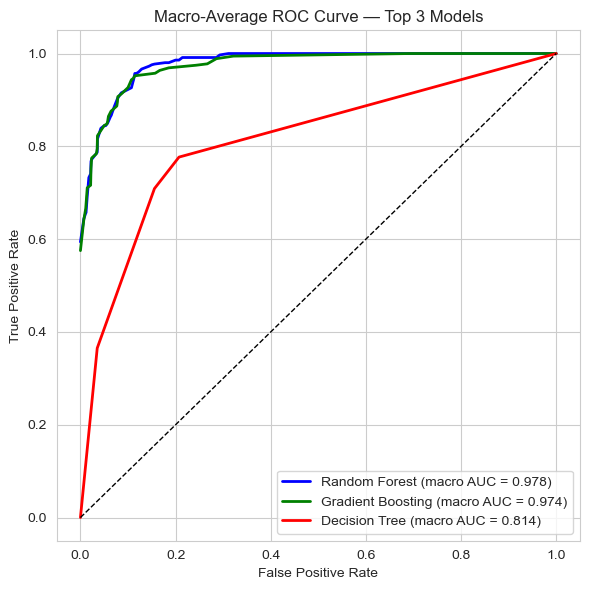

In [209]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(6, 6))

for color_idx, model_name in enumerate(top_3_names):
    model = models[model_name]
    y_score = model.predict_proba(X_test)
    
    # Compute macro-average ROC curve
    fpr_dict, tpr_dict = {}, {}
    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=colors[color_idx], lw=2,
            label=f'{model_name} (macro AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Macro-Average ROC Curve — Top 3 Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_macro_comparison.png', dpi=120)
plt.show()

Top 3 models: ['Random Forest', 'Gradient Boosting', 'Decision Tree']


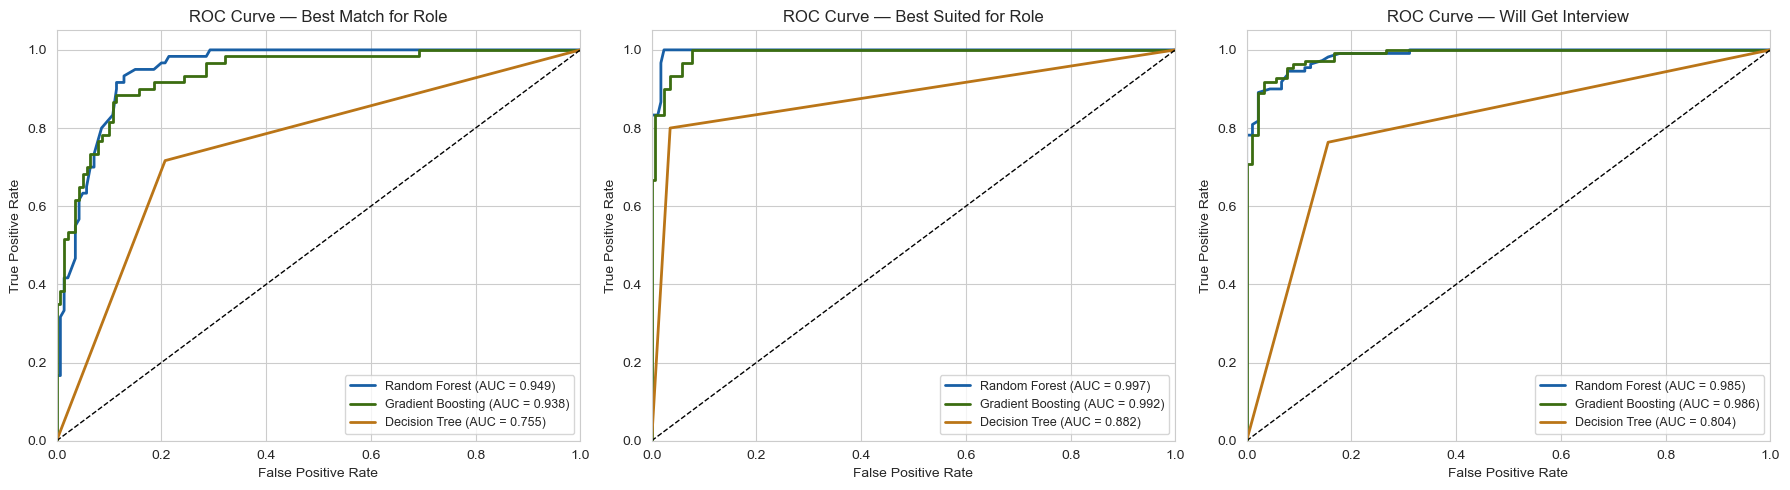

In [222]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Step 1 — Binarize the true labels (One-vs-Rest)
classes = sorted(y_test.unique())  # e.g. ['Best Match for Role', 'Best Suited for Role', 'Will Get Interview']
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# Step 2 — Pick your top 3 models by accuracy (or any metric you like)
top_3_models = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)[:3]
top_3_names = [name for name, _ in top_3_models]

print("Top 3 models:", top_3_names)

# Step 3 — Plot ROC curves
fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5))

colors = ['#185FA5', '#3B6D11', '#BA7517']

for class_idx, class_name in enumerate(classes):
    ax = axes[class_idx]
    
    for color_idx, model_name in enumerate(top_3_names):
        model = models[model_name]
        
        # Get probability scores
        y_score = model.predict_proba(X_test)
        
        # ROC curve for this class
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], y_score[:, class_idx])
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color=colors[color_idx], lw=2,
                label=f'{model_name} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1)  # diagonal baseline
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {class_name}')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=120)
plt.show()

In [212]:
from sklearn.model_selection import GridSearchCV

In [213]:
RandomForestClassifier(random_state=42,class_weight="balanced")

RandomForestClassifier(class_weight='balanced', random_state=42)

In [214]:
parameter_grid = {
    "n_estimators": [50,100, 200],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2, 5 ,10],
    "min_samples_leaf": [1, 2,4]}

In [215]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42,class_weight="balanced"),
                           param_grid = parameter_grid,
                           scoring = "f1",
                           cv=5,
                           n_jobs=-1)

In [216]:
grid_search.fit(X_train_resampled, y_train_resampled)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [217]:
print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [218]:
best_rf = grid_search.best_estimator_

In [219]:
y_pred_best_rf = best_rf.predict(X_test)

In [220]:
print("fine tuned Random forest classifier")
report= classification_report(y_test, y_pred_best_rf)
print(report)

fine tuned Random forest classifier
                      precision    recall  f1-score   support

 Best Match for Role       0.80      0.82      0.81        60
Best Suited for Role       0.88      0.93      0.90        30
  Will Get Interview       0.93      0.91      0.92       110

            accuracy                           0.89       200
           macro avg       0.87      0.89      0.88       200
        weighted avg       0.89      0.89      0.89       200

